In [ ]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [ ]:
!pwd
!ls

In [ ]:
model = YOLO("runs/segment/train2/weights/best.pt")

source_img_path = "dataset/test/images"#/frame8_0003_jpg.rf.5c6f64691140785ee1cd3d2b5343cb75.jpg"
results = model.predict(source=source_img_path, retina_masks=True, conf=0.2, save=False)


image 1/203 /home/phd123/Documents/Amadeus_test/OUR_FOOT/dataset/test/images/frame1_0008_jpg.rf.556405519f39627e83c4304d32dc6795.jpg: 576x1024 1 checkerboard, 1 foot, 47.1ms
image 2/203 /home/phd123/Documents/Amadeus_test/OUR_FOOT/dataset/test/images/frame1_0009_jpg.rf.d0e4fed95ba1751ba83c94985130b418.jpg: 576x1024 1 checkerboard, 1 foot, 4.1ms
image 3/203 /home/phd123/Documents/Amadeus_test/OUR_FOOT/dataset/test/images/frame1_0013_jpg.rf.20a1f6226dbe5ea5ceeb34f85336b93b.jpg: 576x1024 1 checkerboard, 1 foot, 3.7ms
image 4/203 /home/phd123/Documents/Amadeus_test/OUR_FOOT/dataset/test/images/frame1_0013_jpg.rf.62ddadb51b019b562293103604829903.jpg: 576x1024 1 checkerboard, 1 foot, 3.9ms
image 5/203 /home/phd123/Documents/Amadeus_test/OUR_FOOT/dataset/test/images/frame1_0014_jpg.rf.2dd0c151ef8aeb4fa9e3e33b14662e12.jpg: 576x1024 1 checkerboard, 1 foot, 3.9ms
image 6/203 /home/phd123/Documents/Amadeus_test/OUR_FOOT/dataset/test/images/frame1_0019_jpg.rf.012788fd1a9b1fd563f0f5ca6e23940d.jpg:

[7][0]Mask coordinate shape: (910, 2)
[7][1]Mask coordinate shape: (977, 2)
[7][2]Mask coordinate shape: (636, 2)
mask 개수: 3
bbox: [680.4993286132812, 214.49832153320312, 1402.1341552734375, 588.6716918945312] class: 1 conf: 0.9699504971504211
bbox: [604.622802734375, 85.9181137084961, 1429.4342041015625, 680.1414184570312] class: 0 conf: 0.584710419178009
bbox: [605.0455932617188, 89.7490005493164, 1428.199462890625, 426.77764892578125] class: 0 conf: 0.5190286636352539
================ mask 수: 3 ========


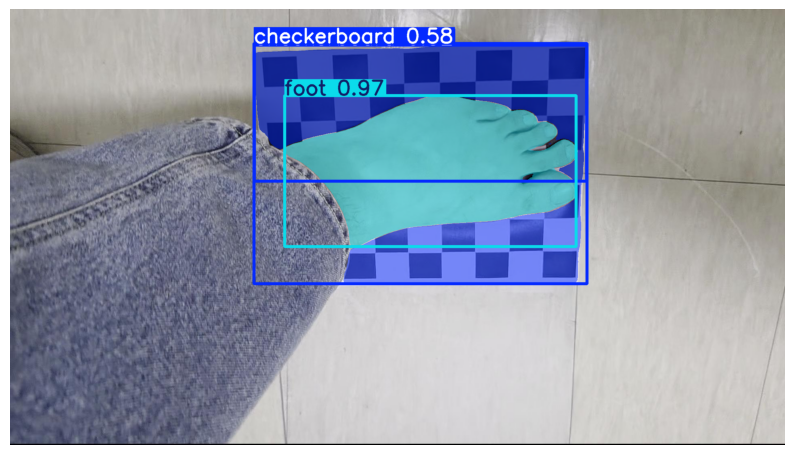

In [7]:
# 나중에 여러 이미지 예측시에도 유연하게 대처하기 위함
for i, result in enumerate(results):
  # ndarray img
  if i!=7:
    continue
  img = result.orig_img

  if result.masks:
    # 마스크 폴리곤 좌표 추출
    # masks.xy: 마스크의 외곽선 xy좌표 리스트 
    for j, mask in enumerate(result.masks.xy):
      # mask는 (N,2) 형태의 Numpy 배열 (각점 xy좌표)
      # 발 외곽선 따라 그리기 등에 사용 가능
      print(f"[{i}][{j}]Mask coordinate shape: {mask.shape}")
      #결과 그려진 이미지 
    print(f"mask 개수: {len(result.masks)}")
    for box, cls, conf in zip(result.boxes.xyxy, result.boxes.cls, result.boxes.conf):
      print("bbox:", box.tolist(), "class:", int(cls), "conf:", float(conf))

    if len(result.masks) != 2:
      #raise RuntimeError("mask수 2개가 아님")
      print(f"================ mask 수: {len(result.masks)} ========")
      img_bgr = result.plot()
      img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

      plt.figure(figsize=(10,10))
      plt.imshow(img_rgb)
      plt.axis("off")
      plt.show()

    if i == 2:
      break



In [ ]:
# mask 실제모습 (0과 1로 이루어짐)
old_opts = np.get_printoptions()
np.set_printoptions(threshold=np.inf)
for i, result in enumerate(results):
  # ndarray img
  img = result.orig_img

  if result.masks:
    for j, mask in enumerate(result.masks):
      mask_raw = mask.data[0].cpu().numpy()
      print(mask_raw)
  if i == 0:
    break

  np.set_printoptions(**old_opts)

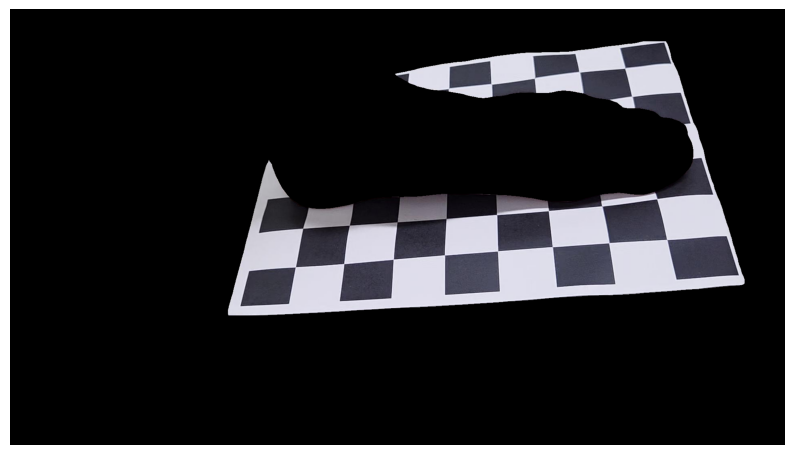

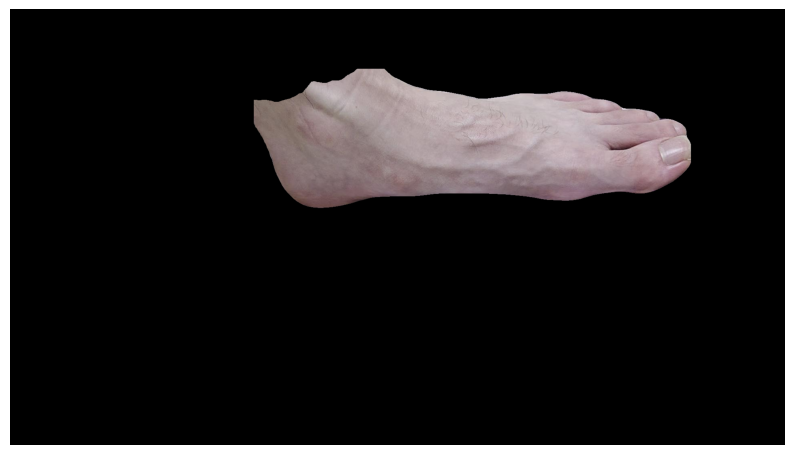

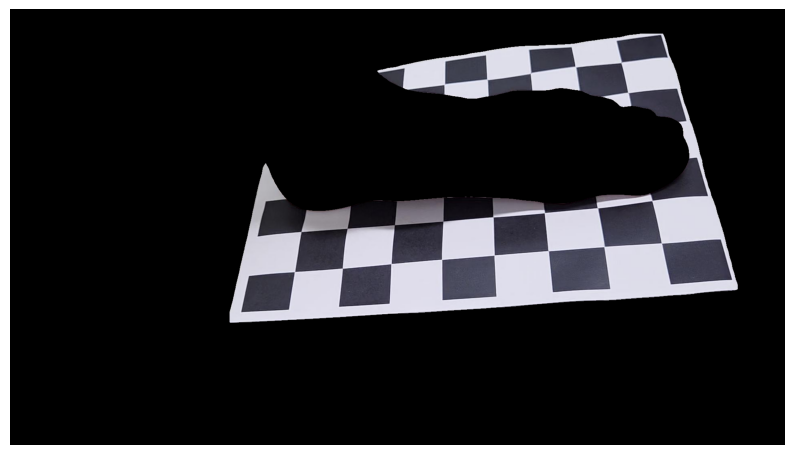

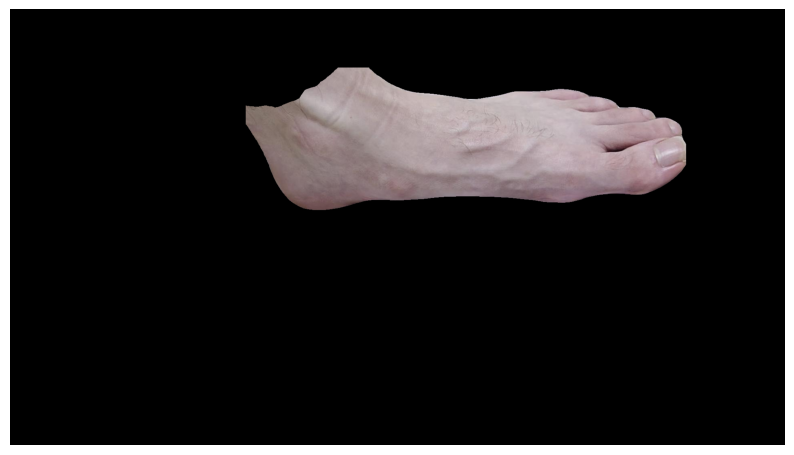

KeyboardInterrupt: Interrupted by user

In [39]:
for i, result in enumerate(results):
  # ndarray img
  img = result.orig_img

  if result.masks:
    for j, mask in enumerate(result.masks):
      # binary mask
      mask_raw = mask.data[0].cpu().numpy()

      # 마스크 크기를 원본 이미지 사이즈로 리사이즈
      h, w, c = img.shape
      mask_resized = cv2.resize(mask_raw, (w, h))

      # cv2.bitwise_and가 원하는 0 or 255 마스크로 변환
      binary_mask = mask_resized.astype("uint8")*255
      segmented = cv2.bitwise_and(img, img, mask=binary_mask)
      seg_rgb = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)

      plt.figure(figsize=(10,10))
      plt.imshow(seg_rgb)
      plt.axis("off")
      #plt.savefig(f"[{i}][{j}] segmented (bitwise_and).jpg")
      #cv2.imwrite(f"[{i}][{j}] segmented.jpg", segmented)

      
      img_pil = Image.fromarray(seg_rgb)
      img_pil.save(f"[{i}][{j}] segmented.jpg")
      
      plt.show()
      input()
      


체커보드 bbox: 2, mask: 2
checkerboard 그룹: [[0, 1]]


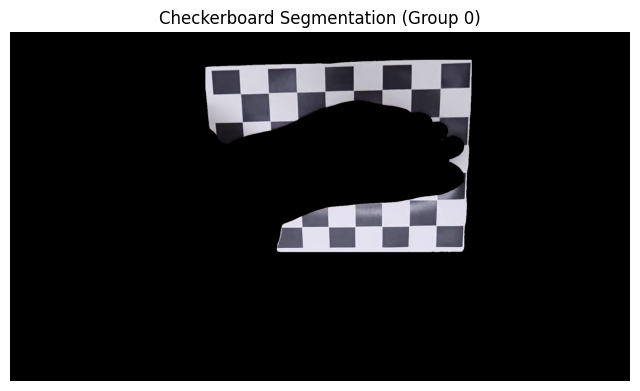

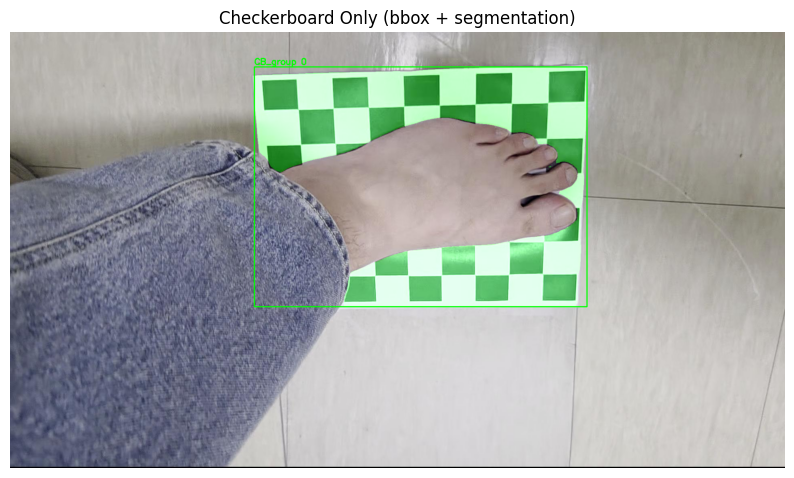

In [13]:
def box_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    if inter <= 0:
        return 0.0
    area1 = (box1[2]-box1[0])*(box1[3]-box1[1])
    area2 = (box2[2]-box2[0])*(box2[3]-box2[1])
    return inter / (area1 + area2 - inter)


for i, result in enumerate(results):

    if i != 7:
        continue

    img = result.orig_img.copy()
    show_img = img.copy()
    h, w, c = img.shape

    # ============================
    # 1. 클래스 0(체커보드)만 필터링
    # ============================
    boxes_all = result.boxes.xyxy.tolist()
    classes_all = result.boxes.cls.tolist()
    confs_all = result.boxes.conf.tolist()
    masks_raw_all = [m.cpu().numpy() for m in result.masks.data]

    # 필터링된 index
    cb_idx = [k for k, cls in enumerate(classes_all) if int(cls) == 0]

    if len(cb_idx) == 0:
        print("checkerboard(class 0)이 없음")
        break

    boxes = [boxes_all[k] for k in cb_idx]
    confs = [confs_all[k] for k in cb_idx]
    masks_raw = [masks_raw_all[k] for k in cb_idx]

    print(f"체커보드 bbox: {len(boxes)}, mask: {len(masks_raw)}")

    # ============================
    # 2. IoU 기반 그룹핑
    # ============================
    iou_thresh = 0.3
    groups = []
    used = set()

    for idx in range(len(boxes)):
        if idx in used:
            continue

        group = [idx]
        used.add(idx)

        for j in range(len(boxes)):
            if j in used:
                continue
            if box_iou(boxes[idx], boxes[j]) >= iou_thresh:
                group.append(j)
                used.add(j)

        groups.append(group)

    print("checkerboard 그룹:", groups)

    # ============================
    # 3. 그룹별 segmentation 생성
    # ============================
    for gi, group in enumerate(groups):

        # 1) 그룹 mask OR 결합
        merged = np.zeros((h, w), dtype=np.uint8)

        for mi in group:
            mask_resized = cv2.resize(masks_raw[mi], (w, h))
            merged = np.logical_or(merged, (mask_resized > 0.5))

        merged = merged.astype(np.uint8) * 255

        # 2) segmentation
        seg = cv2.bitwise_and(img, img, mask=merged)

        # 3) 새로운 bbox — merged mask 기반
        ys, xs = np.where(merged > 0)
        if len(xs) == 0:
            continue
        x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)

        # 4) show 이미지에 그리기
        cv2.rectangle(show_img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(show_img,
                    f"CB_group {gi}",
                    (x1, y1 - 6),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (0,255,0), 2)

        # segmentation overlay
        color_mask = np.zeros_like(img)
        color_mask[:, :, 1] = merged  # green 채널 사용
        show_img = cv2.addWeighted(show_img, 1.0, color_mask, 0.4, 0)

        # 별도로 segmentation 자체 확인
        seg_rgb = cv2.cvtColor(seg, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8,8))
        plt.imshow(seg_rgb)
        plt.title(f"Checkerboard Segmentation (Group {gi})")
        plt.axis("off")
        plt.show()

    # ============================
    # 4. 최종 bbox + segmentation 결과 출력
    # ============================
    show_img_rgb = cv2.cvtColor(show_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,10))
    plt.imshow(show_img_rgb)
    plt.title("Checkerboard Only (bbox + segmentation)")
    plt.axis("off")
    plt.show()

    break
